CODE FOR EXPERIMENT 1

In [2]:
!pip install conllu pandas tqdm matplotlib

In [3]:
import os
import requests
import zipfile

languages = {
    "en": "UD_English-EWT",
    "hi": "UD_Hindi-HDTB",
    "es": "UD_Spanish-GSD",
    "de": "UD_German-GSD",
    "ru": "UD_Russian-GSD",
    "tr": "UD_Turkish-IMST",
    "ja": "UD_Japanese-GSD",
    "zh": "UD_Chinese-GSD",
    "ar": "UD_Arabic-PADT",
    "fi": "UD_Finnish-TDT"
}

def download_treebank(lang_name):
    url = f"https://github.com/UniversalDependencies/{lang_name}/archive/refs/heads/master.zip"
    zip_path = f"{lang_name}.zip"

    if not os.path.exists(zip_path):
        r = requests.get(url)
        with open(zip_path, "wb") as f:
            f.write(r.content)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data")

for lang in languages.values():
    download_treebank(lang)

print("All treebanks downloaded")

All treebanks downloaded


In [4]:
from conllu import parse
from pathlib import Path

def load_sentences(lang_name):
    folder = Path(f"data/{lang_name}-master")
    files = list(folder.glob("*.conllu"))

    sentences = []
    for file in files:
        with open(file, "r", encoding="utf-8") as f:
            sentences.extend(parse(f.read()))

    return sentences

In [5]:
from collections import defaultdict

def compute_children(sentence):
    children = defaultdict(list)
    for tok in sentence:
        if tok["head"] is not None:
            children[tok["head"]].append(tok["id"])
    return children

In [6]:
def get_interveners(head, dep):
    if head < dep:
        return list(range(head+1, dep))
    else:
        return list(range(dep+1, head))

In [7]:
def phrase_length(node_id, children):
    stack = [node_id]
    size = 0

    while stack:
        curr = stack.pop()
        size += 1
        stack.extend(children[curr])

    return size

In [8]:
import pandas as pd
from tqdm import tqdm

data = []

for lang_code, lang_name in languages.items():

    sentences = load_sentences(lang_name)

    for sentence in tqdm(sentences, desc=lang_code):

        children = compute_children(sentence)
        token_map = {t["id"]: t for t in sentence if isinstance(t["id"], int)}

        for token in sentence:

            if not isinstance(token["id"], int):
                continue

            head = token["head"]
            dep = token["id"]

            if head == 0 or head is None:
                continue

            interveners = get_interveners(head, dep)

            for i in interveners:

                if i not in token_map:
                    continue

                t = token_map[i]

                data.append({
                    "language": lang_code,
                    "upos": t["upostag"],
                    "arity": len(children[i]),
                    "phrase_len": phrase_length(i, children)
                })

df = pd.DataFrame(data)
print("Total interveners:", len(df))

fi: 100%|██████████| 15136/15136 [00:00<00:00, 15989.54it/s]


Total interveners: 5416707


In [9]:
pos_dist = df["upos"].value_counts(normalize=True) * 100
print(pos_dist.head(10))

upos
NOUN     21.814970
ADP      16.842779
ADJ       8.300117
DET       8.179841
PUNCT     7.927658
PROPN     7.431785
VERB      4.708636
AUX       4.390490
PRON      4.293679
CCONJ     4.037268
Name: proportion, dtype: float64


In [10]:
arity_dist = df["arity"].value_counts(normalize=True) * 100
print(arity_dist.head(10))

arity
0    70.465598
1    13.388153
2     8.791688
3     4.246639
4     1.827125
5     0.771262
6     0.317887
7     0.123784
8     0.042664
9     0.015009
Name: proportion, dtype: float64


In [11]:
phrase_dist = df["phrase_len"].value_counts(normalize=True) * 100
print(phrase_dist.head(10))

phrase_len
1     70.465598
2     10.317080
3      5.941359
4      3.189853
5      2.181879
6      1.557127
7      1.126829
8      0.854209
9      0.675337
10     0.528273
Name: proportion, dtype: float64


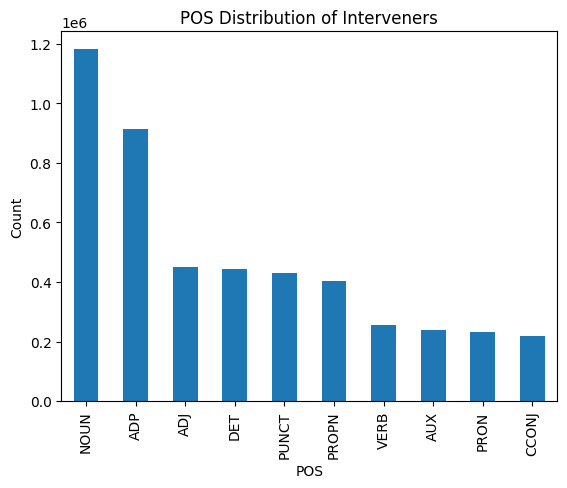

In [12]:
import matplotlib.pyplot as plt

df["upos"].value_counts().head(10).plot(kind="bar")
plt.title("POS Distribution of Interveners")
plt.xlabel("POS")
plt.ylabel("Count")
plt.show()

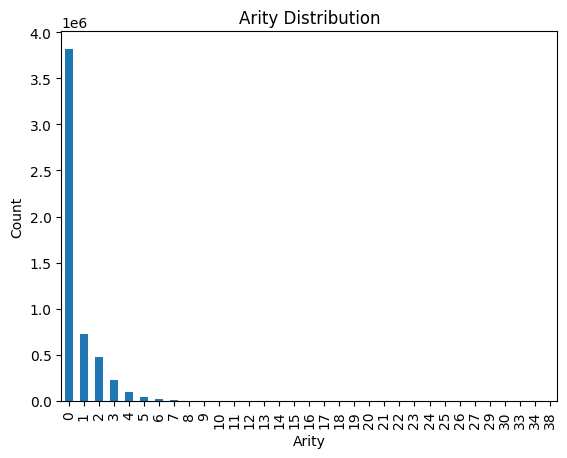

In [13]:
df["arity"].value_counts().sort_index().plot(kind="bar")
plt.title("Arity Distribution")
plt.xlabel("Arity")
plt.ylabel("Count")
plt.show()

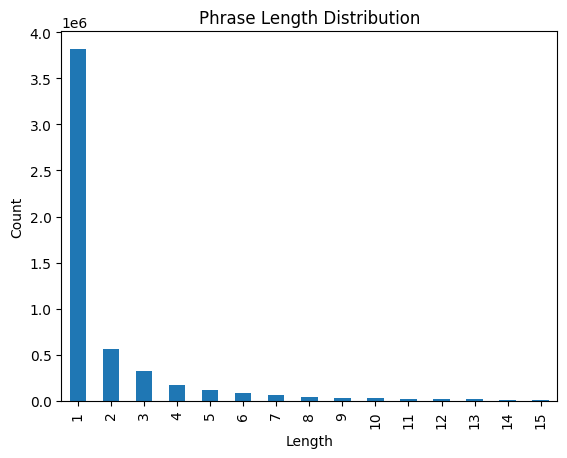

In [14]:
df["phrase_len"].value_counts().sort_index().head(15).plot(kind="bar")
plt.title("Phrase Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [15]:
lang_summary = df.groupby("language").agg({
    "arity": "mean",
    "phrase_len": "mean"
})

print(lang_summary)

             arity  phrase_len
language                      
ar        0.731465    3.371172
de        0.572531    2.015764
en        0.496732    1.962636
es        0.571231    2.271311
fi        0.513198    2.011276
hi        0.589926    2.149216
ja        0.455161    1.867779
ru        0.576333    2.186068
tr        0.531458    1.991602
zh        0.604298    2.066251


CODE FOR EXPERIMENT 2


In [16]:
import pandas as pd
from tqdm import tqdm

dep_data = []

for lang_code, lang_name in languages.items():

    sentences = load_sentences(lang_name)

    for sentence in tqdm(sentences, desc=lang_code):

        children = compute_children(sentence)
        token_map = {t["id"]: t for t in sentence if isinstance(t["id"], int)}

        for token in sentence:

            if not isinstance(token["id"], int):
                continue

            head = token["head"]
            dep = token["id"]

            if head == 0 or head is None:
                continue

            distance = abs(head - dep)
            interveners = get_interveners(head, dep)

            if len(interveners) == 0:
                continue

            arities = []
            phrase_lengths = []

            for i in interveners:

                if i not in token_map:
                    continue

                arities.append(len(children[i]))
                phrase_lengths.append(phrase_length(i, children))

            if len(arities) == 0:
                continue

            dep_data.append({
                "language": lang_code,
                "distance": distance,
                "num_interveners": len(arities),
                "avg_arity": sum(arities)/len(arities),
                "avg_phrase_len": sum(phrase_lengths)/len(phrase_lengths)
            })

dep_df = pd.DataFrame(dep_data)
print(dep_df.shape)

fi: 100%|██████████| 15136/15136 [00:00<00:00, 19998.30it/s]


(1178324, 5)


In [17]:
def distance_bin(d):
    if d <= 2:
        return "1-2"
    elif d <= 5:
        return "3-5"
    else:
        return "6+"

dep_df["dist_bin"] = dep_df["distance"].apply(distance_bin)

In [18]:
summary = dep_df.groupby("dist_bin").agg({
    "num_interveners": "mean",
    "avg_arity": "mean",
    "avg_phrase_len": "mean"
})

print(summary)

          num_interveners  avg_arity  avg_phrase_len
dist_bin                                            
1-2              1.000000   0.005266        1.027189
3-5              2.653725   0.203034        1.263260
6+              12.250399   0.654518        2.214805


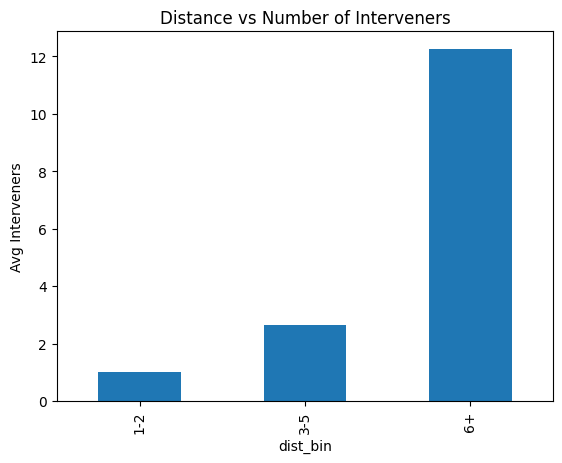

In [19]:
summary["num_interveners"].plot(kind="bar")
plt.title("Distance vs Number of Interveners")
plt.ylabel("Avg Interveners")
plt.show()

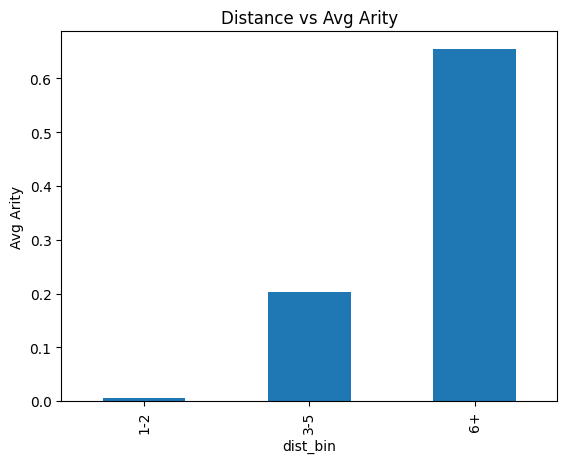

In [20]:
summary["avg_arity"].plot(kind="bar")
plt.title("Distance vs Avg Arity")
plt.ylabel("Avg Arity")
plt.show()

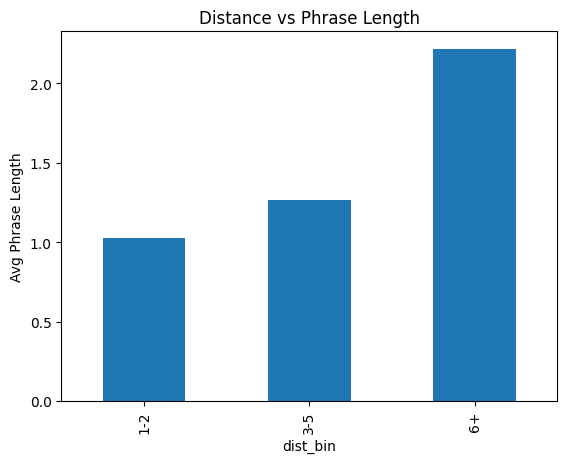

In [21]:
summary["avg_phrase_len"].plot(kind="bar")
plt.title("Distance vs Phrase Length")
plt.ylabel("Avg Phrase Length")
plt.show()

CODE FOR EXPERMENT 3

In [32]:
import pandas as pd
from tqdm import tqdm

sent_data = []

for lang_code, lang_name in languages.items():

    sentences = load_sentences(lang_name)

    for sentence in tqdm(sentences, desc=lang_code):

        # sentence length
        tokens = [t for t in sentence if isinstance(t["id"], int)]
        sent_len = len(tokens)

        children = compute_children(sentence)
        token_map = {t["id"]: t for t in sentence if isinstance(t["id"], int)}

        for token in sentence:

            if not isinstance(token["id"], int):
                continue

            head = token["head"]
            dep = token["id"]

            if head == 0 or head is None:
                continue

            interveners = get_interveners(head, dep)

            if len(interveners) == 0:
                continue

            arities = []
            phrase_lengths = []

            for i in interveners:

                if i not in token_map:
                    continue

                arities.append(len(children[i]))
                phrase_lengths.append(phrase_length(i, children))

            if len(arities) == 0:
                continue

            sent_data.append({
                "language": lang_code,
                "sentence_length": sent_len,
                "num_interveners": len(arities),
                "avg_arity": sum(arities) / len(arities),
                "avg_phrase_len": sum(phrase_lengths) / len(phrase_lengths)
            })

sent_df = pd.DataFrame(sent_data)
print(sent_df.shape)

fi: 100%|██████████| 15136/15136 [00:00<00:00, 18399.86it/s]


(1178324, 5)


In [33]:
def length_bin(x):
    if x <= 10:
        return "short"
    elif x <= 20:
        return "medium"
    else:
        return "long"

sent_df["len_bin"] = sent_df["sentence_length"].apply(length_bin)

In [34]:
sent_summary = sent_df.groupby("len_bin")[[
    "num_interveners", "avg_arity", "avg_phrase_len"
]].mean()

print(sent_summary)

         num_interveners  avg_arity  avg_phrase_len
len_bin                                            
long            5.237011   0.257120        1.475461
medium          3.530112   0.239329        1.355432
short           2.265288   0.183909        1.225562


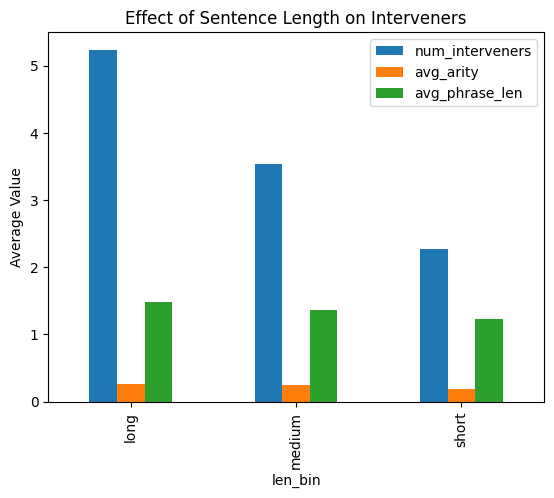

In [35]:
import matplotlib.pyplot as plt

sent_summary.plot(kind="bar")
plt.title("Effect of Sentence Length on Interveners")
plt.ylabel("Average Value")
plt.show()

CODE FOR EXPERIMENT 4


In [27]:
dep_rel_data = []

for lang_code, lang_name in languages.items():

    sentences = load_sentences(lang_name)

    for sentence in tqdm(sentences, desc=lang_code):

        children = compute_children(sentence)
        token_map = {t["id"]: t for t in sentence if isinstance(t["id"], int)}

        for token in sentence:

            if not isinstance(token["id"], int):
                continue

            head = token["head"]
            dep = token["id"]
            rel = token["deprel"]

            if head == 0 or head is None:
                continue

            distance = abs(head - dep)
            interveners = get_interveners(head, dep)

            if len(interveners) == 0:
                continue

            arities = []
            phrase_lengths = []
            pos_list = []

            for i in interveners:

                if i not in token_map:
                    continue

                t = token_map[i]

                arities.append(len(children[i]))
                phrase_lengths.append(phrase_length(i, children))
                pos_list.append(t["upostag"])

            if len(arities) == 0:
                continue

            dep_rel_data.append({
                "language": lang_code,
                "relation": rel,
                "distance": distance,
                "num_interveners": len(arities),
                "avg_arity": sum(arities)/len(arities),
                "avg_phrase_len": sum(phrase_lengths)/len(phrase_lengths),
                "dominant_pos": max(set(pos_list), key=pos_list.count)
            })

rel_df = pd.DataFrame(dep_rel_data)
print(rel_df.shape)

fi: 100%|██████████| 15136/15136 [00:01<00:00, 11433.23it/s]


(1178324, 7)


In [28]:
top_relations = rel_df["relation"].value_counts().head(5).index
rel_df_filtered = rel_df[rel_df["relation"].isin(top_relations)]

In [29]:
rel_summary = rel_df_filtered.groupby("relation").agg({
    "num_interveners": "mean",
    "avg_arity": "mean",
    "avg_phrase_len": "mean"
})

print(rel_summary)

          num_interveners  avg_arity  avg_phrase_len
relation                                            
case             1.471670   0.054995        1.076043
nmod             2.388963   0.099799        1.151042
nsubj            4.468245   0.302526        1.507348
obl              4.909447   0.295291        1.481562
punct            9.436706   0.488523        1.963542


In [30]:
pos_rel = rel_df_filtered.groupby(["relation", "dominant_pos"]).size().unstack(fill_value=0)

# convert to %
pos_rel = pos_rel.div(pos_rel.sum(axis=1), axis=0) * 100

print(pos_rel)

dominant_pos        ADJ        ADP       ADV        AUX     CCONJ        DET  \
relation                                                                       
case          14.140299  12.947633  0.874826   1.723081  1.393999  48.780762   
nmod           7.430842  56.959383  0.856429   0.585259  1.265461   5.928026   
nsubj          7.490827  18.789206  9.254350  16.822109  1.332702   6.813824   
obl            5.438323  47.141200  3.869884   2.162205  0.721802   5.487136   
punct          5.251743   9.256607  4.687052  12.543623  3.604436   6.822473   

dominant_pos      INTJ       NOUN       NUM      PART      PRON     PROPN  \
relation                                                                    
case          0.003066   3.575955  5.133472  0.553920  2.424168  3.976576   
nmod          0.001301   6.939874  3.452379  1.408524  2.031500  6.598473   
nsubj         0.031956  14.552018  2.297313  1.459344  6.638655  8.367854   
obl           0.001600  15.681991  3.139279  0.552155 

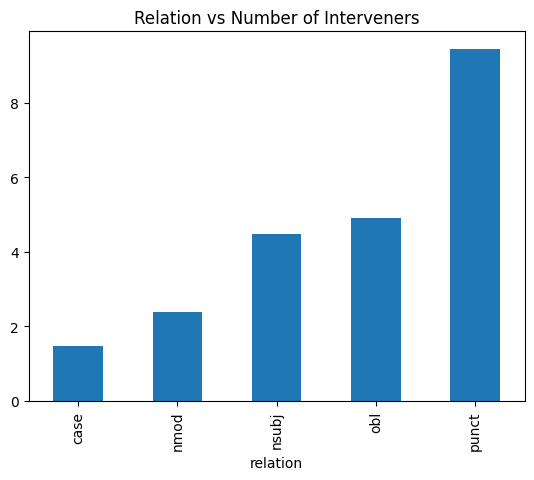

In [31]:
rel_summary["num_interveners"].plot(kind="bar")
plt.title("Relation vs Number of Interveners")
plt.show()

CODE FOR EXPERIMENT 5: we dont need it because we can interpret results of this section from the results of previous experiments